<a href="https://colab.research.google.com/github/AsherWood39/ACM_GitHub_Practice/blob/main/Useless.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opencv-python numpy

In [3]:
import cv2
import numpy as np
import os

def detect_creases(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Unable to load image at {image_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (9, 9), 0)

    edges = cv2.Canny(blurred, 30, 90, apertureSize=3)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_image = np.zeros_like(img)

    cv2.drawContours(contour_image, contours, -1, (255, 255, 255), 2)

    final_image = cv2.addWeighted(img, 0.8, contour_image, 1, 0)

    output_path = "traced_creases.png"
    cv2.imwrite(output_path, final_image)
    print(f"Traced image saved to {output_path}")
    return output_path

image_file = 'crumbled.jpeg'
traced_image = detect_creases(image_file)

Traced image saved to traced_creases.png


In [4]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 5.9 MB/s eta 0:00:00


In [7]:
import base64
import os
from groq import Groq
from google.colab import userdata

def get_groq_interpretation(image_path):
    api_key = userdata.get('GROQ_API_KEY')
    if not api_key:
        raise ValueError("GROQ_API_KEY not found in Colab Secrets.")

    client = Groq(api_key=api_key)

    with open(image_path, "rb") as image_file:
        base64_image = base64.b64encode(image_file.read()).decode("utf-8")

    prompt_content = [
        {"type": "text",
         "text": """
         You are the "Creased Paper Comedy Oracle." Your job is to look at the lines in an image and find a ridiculous, hilarious, or absurdly specific pattern within the chaos. You must then invent a short, comedic backstory for this pattern. Do not follow a rigid "Label" and "Story" format. Instead, combine them into a single, cohesive, and funny narrative.
        Here are your guidelines:

        * **Be a Comedic Narrator:** Speak as if you're telling a grand, over-the-top story.
        * **Absurdity is Key:** Find the funniest, most unexpected thing the lines could possibly represent. Think of mythical creatures, confused animals, or bizarre everyday objects.
        * **Weave the Story:** Invent a short, detailed, and completely ridiculous backstory for your interpretation. The story should be 2-5 sentences long and feel like a mix of a whimsical children's book and stand-up comedy.
        * **Be Specific:** Instead of "a dragon," say "a sleep-deprived dragon." Instead of "a wizard," say "a banana wizard."
        * **The Goal:** Your entire response should be one continuous, imaginative interpretation that fully embodies your persona as the oracle.

        Example of the kind of output I'm looking for:

        "Ah, the creases speak! I see it now: it's 'The Spaghetti Yeti'! Legend says this beast roams the Italian Alps, guarding the secret to the world’s fluffiest meatballs. He only reveals himself when someone spills pasta sauce, and his laugh sounds suspiciously like boiling water."
         """},
        {"type": "image_url",
         "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
    ]

    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt_content}],
        model="meta-llama/llama-4-scout-17b-16e-instruct"
    )

    interpretations = chat_completion.choices[0].message.content
    print("Groq's interpretations:")
    print(interpretations)
    return interpretations

text = get_groq_interpretation(traced_image)
print(text)

Groq's interpretations:
The creased chaos before me holds secrets and tales of old! I see it now: a majestic, bewildered Bonsai T-Rex, sporting a haircut that screams "I was styled by a hurricane." This pint-sized, leafy tyrant rules over the Land of Tiny Landscapes, where trees are pruned into perpetual confusion and the creatures are always arguing over whose turn it is to water the plants. Legend says that on Wednesdays, the Bonsai T-Rex descends from its miniature mountain to compete in the World Championships of Tiny Golf, using a toothpick as a trusty club. Its arch-nemesis, a rogue Pruning Shear named Steve, constantly plots to give the Bonsai T-Rex a mullet, thus ruining its carefully coiffed dignity.
The creased chaos before me holds secrets and tales of old! I see it now: a majestic, bewildered Bonsai T-Rex, sporting a haircut that screams "I was styled by a hurricane." This pint-sized, leafy tyrant rules over the Land of Tiny Landscapes, where trees are pruned into perpetual

In [8]:
import os
from huggingface_hub import InferenceClient
from google.colab import userdata

api_key = userdata.get("HF_API_KEY")

client = InferenceClient(
    provider="fal-ai",
    api_key=api_key,
)

image = client.text_to_image(
    text,
    model="stabilityai/stable-diffusion-3-medium",
)

image.save("image.png")
print("Image generated and saved successfully.")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Image generated and saved successfully.


In [ ]:
!pip install requests
!pip install -U diffusers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 37.2 MB/s eta 0:00:00


In [ ]:
import requests
import os
from google.colab import userdata

API_BASE_URL = "https://huggingface.co/models/"

HF_API_KEY = userdata.get('HF_API_KEY')

def generate_backstory(interpretation_text):
    text_model_id = "mistralai/Mistral-7B-Instruct-v0.2"
    text_api_url = f"{API_BASE_URL}{text_model_id}"
    text_headers = {"Authorization": f"Bearer {HF_API_KEY}"}

    story_prompt = f"Write a one-paragraph fantasy backstory for an image depicting '{interpretation_text}'."

    text_response = requests.post(text_api_url, headers=text_headers, json={"inputs": story_prompt})

    if text_response.status_code == 200:
        try:
            backstory = text_response.json()[0]["generated_text"]
            clean_backstory = backstory.split(story_prompt)[-1].strip()
            print("\nGenerated Backstory:")
            print(clean_backstory)
        except requests.exceptions.JSONDecodeError:
            print(f"Backstory generation failed: JSONDecodeError occurred. The response content was: '{text_response.text}'")
    else:
        print(f"Backstory generation failed with status code {text_response.status_code}.")
        try:
            error_message = text_response.json().get('error', 'No error message provided.')
            print(f"Error message: {error_message}")
        except requests.exceptions.JSONDecodeError:
            print("Server returned a non-JSON error response.")

sample_interpretation = "A map of a hidden kingdom where rivers are made of starlight."
generate_image(sample_interpretation)

Image generation failed with status code 404.
Server returned a non-JSON error response. The model may be loading or unavailable.
Backstory generation failed with status code 404.
Server returned a non-JSON error response.


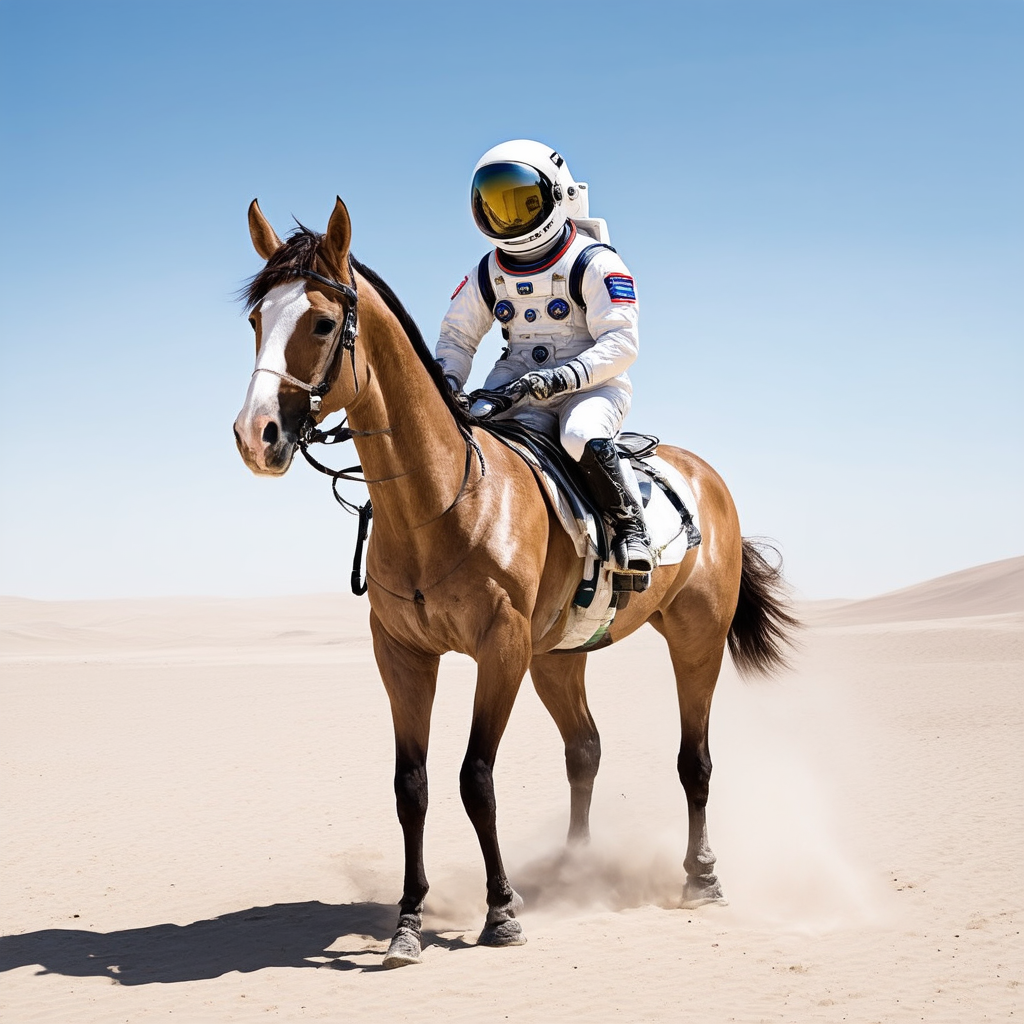

In [ ]:
from PIL import Image
from IPython.display import display

# Open the saved image file
image = Image.open("astronaut.png")

# Display the image in the notebook output
display(image)